In [1]:
# IMPORT LIBRARIES
# ================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,silhouette_score)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
# LOAD DATASET:
# =============

df = pd.read_csv("Country-data.csv")
print(df.head())
print(df.shape)

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
(167, 10)


In [3]:
# DATA PREPROCESSING:
# ===================

print(df.info())
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
encoder = LabelEncoder()
df["country"] = encoder.fit_transform(df["country"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


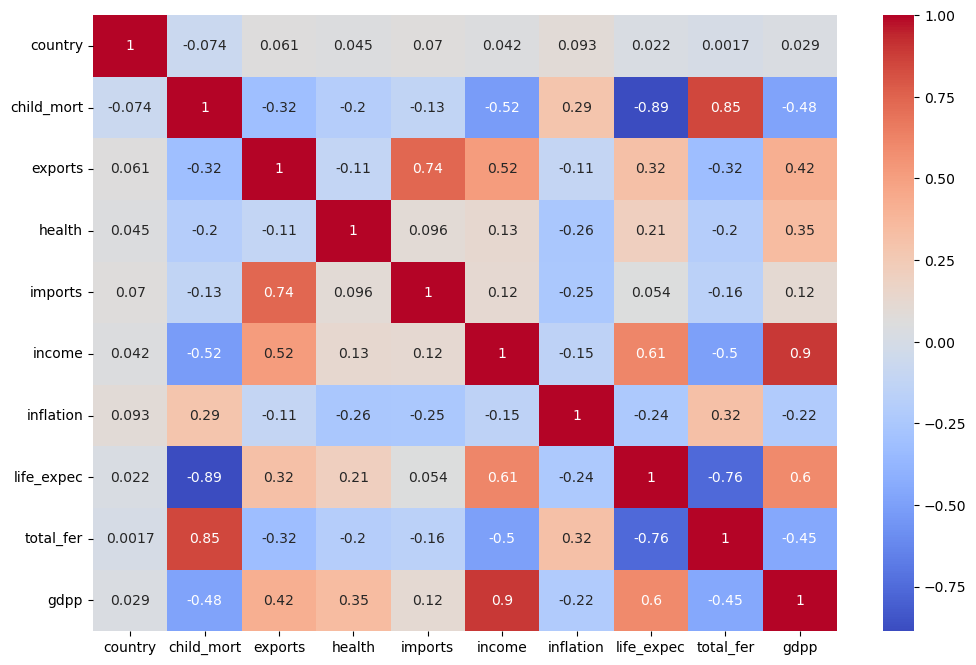

In [4]:
# EXPLORATORY DATA ANALYSIS
# =========================
# Distribution plots
# Correlation heatmap
# Boxplots
# Pairplots (optional)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [5]:
# # FEATURE ENGINEERING
# =====================

median_income = df["income"].median()
df["Target"] = np.where(df["income"] >= median_income, 1, 0)
print(df["Target"].value_counts())

Target
1    84
0    83
Name: count, dtype: int64


In [6]:
# FEATURE SCALING
# ===============

X = df.drop(["Target", "income"], axis=1)
y = df["Target"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# TRAIN-TEST SPLIT
# ================

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.35,random_state=42,stratify=y)

In [8]:
# RANDOM FOREST CLASSIFIER
# ========================

rf = RandomForestClassifier(n_estimators=50,max_depth=3,min_samples_split=15,min_samples_leaf=8,max_features='sqrt',random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8983050847457628
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        29
           1       1.00      0.80      0.89        30

    accuracy                           0.90        59
   macro avg       0.91      0.90      0.90        59
weighted avg       0.92      0.90      0.90        59



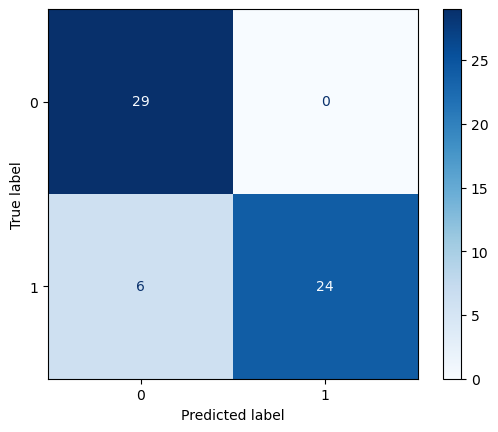

In [9]:
# CONFUSION MATRIX
# ================

ConfusionMatrixDisplay.from_predictions(y_test,rf_pred,cmap="Blues")
plt.show()

In [10]:
# XGBOOST CLASSIFIER
# ==================

xgb = XGBClassifier(n_estimators=50,learning_rate=0.05,max_depth=2,subsample=0.4,colsample_bytree=0.4,random_state=42,eval_metric="logloss")
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost Accuracy:",accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9152542372881356
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        29
           1       0.96      0.87      0.91        30

    accuracy                           0.92        59
   macro avg       0.92      0.92      0.92        59
weighted avg       0.92      0.92      0.92        59



In [11]:
# COMPARISON BETWEEN MODELS
# =========================

comparison = pd.DataFrame({"Model": ["Random Forest", "XGBoost"],"Accuracy": [accuracy_score(y_test, rf_pred),accuracy_score(y_test, xgb_pred)]})
print(comparison)

           Model  Accuracy
0  Random Forest  0.898305
1        XGBoost  0.915254


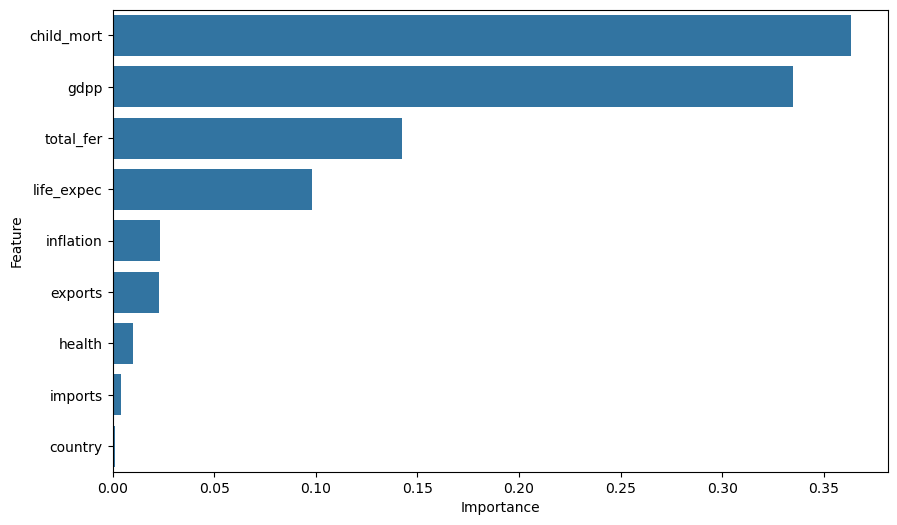

In [12]:
# FEATURE IMPORTANCE
# ==================

importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.show()